In [1]:
print("Wake Up...Let's start the project")

Wake Up...Let's start the project


In [2]:
import numpy as np
import pandas as pd     

df = pd.read_csv("netflix_titles.csv")
print(df)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

In [3]:
import pandas as pd

# Load
df = pd.read_csv('netflix_titles.csv')

print("Before cleaning:", df.shape)

# 1. Fill missing text columns with 'Unknown'
#df['director'].fillna('Unknown', inplace=True)
#df['cast'].fillna('Unknown', inplace=True)
#df['country'].fillna('Unknown', inplace=True)

# OLD way (causes warning, doesn't work in pandas v2+)
# df['director'].fillna('Unknown', inplace=True)

# NEW correct way
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# 2. Drop rows where important columns are missing
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

print("After cleaning:", df.shape)

# 3. Fix date_added — convert to proper datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# 4. Extract year and month from date_added (useful for trends later)
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# 5. Confirm no more nulls
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nSample cleaned data:")
print(df[['title', 'type', 'country', 'date_added', 'year_added']].head(5))

Before cleaning: (8807, 12)
After cleaning: (8790, 12)

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Sample cleaned data:
                   title     type        country date_added  year_added
0   Dick Johnson Is Dead    Movie  United States 2021-09-25        2021
1          Blood & Water  TV Show   South Africa 2021-09-24        2021
2              Ganglands  TV Show        Unknown 2021-09-24        2021
3  Jailbirds New Orleans  TV Show        Unknown 2021-09-24        2021
4           Kota Factory  TV Show          India 2021-09-24        2021


C:\Users\DELL\AppData\Local\Temp\ipykernel_3604\2262845037.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'].str.strip())


In [4]:
pip install matplotlib seaborn  

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 311.3 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.5 MB 311.3 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.5 MB 311.3 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.5 MB 311.3 kB/s eta 0:00:29
   --- ------------------------------------ 0.8/9.5 MB 326.2 kB/s e


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

# ── 1. Movies vs TV Shows ──────────────────────────────────────
type_counts = df['type'].value_counts()
print("Movies vs TV Shows:")
print(type_counts)

# ── 2. Top 10 Countries ────────────────────────────────────────
top_countries = df['country'].value_counts().head(10)
print("\nTop 10 Countries:")
print(top_countries)

# ── 3. Content Added Per Year ──────────────────────────────────
yearly = df['year_added'].value_counts().sort_index()
print("\nContent Added Per Year:")
print(yearly)

# ── 4. Top 10 Genres ──────────────────────────────────────────
# listed_in has multiple genres per row like "Dramas, International Movies"
# so we split and count individually
all_genres = df['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)
print("\nTop 10 Genres:")
print(top_genres)

# ── 5. Rating Distribution ────────────────────────────────────
rating_counts = df['rating'].value_counts()
print("\nRating Distribution:")
print(rating_counts)

Movies vs TV Shows:
type
Movie      6126
TV Show    2664
Name: count, dtype: int64

Top 10 Countries:
country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

Content Added Per Year:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

Rating 

C:\Users\DELL\AppData\Local\Temp\ipykernel_3604\3530442736.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index,
C:\Users\DELL\AppData\Local\Temp\ipykernel_3604\3530442736.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index,
C:\Users\DELL\AppData\Local\Temp\ipykernel_3604\3530442736.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values,
C:\Users\DELL\AppData\Local\Temp\ipykernel_3604\3530442736.py:53: FutureWarn

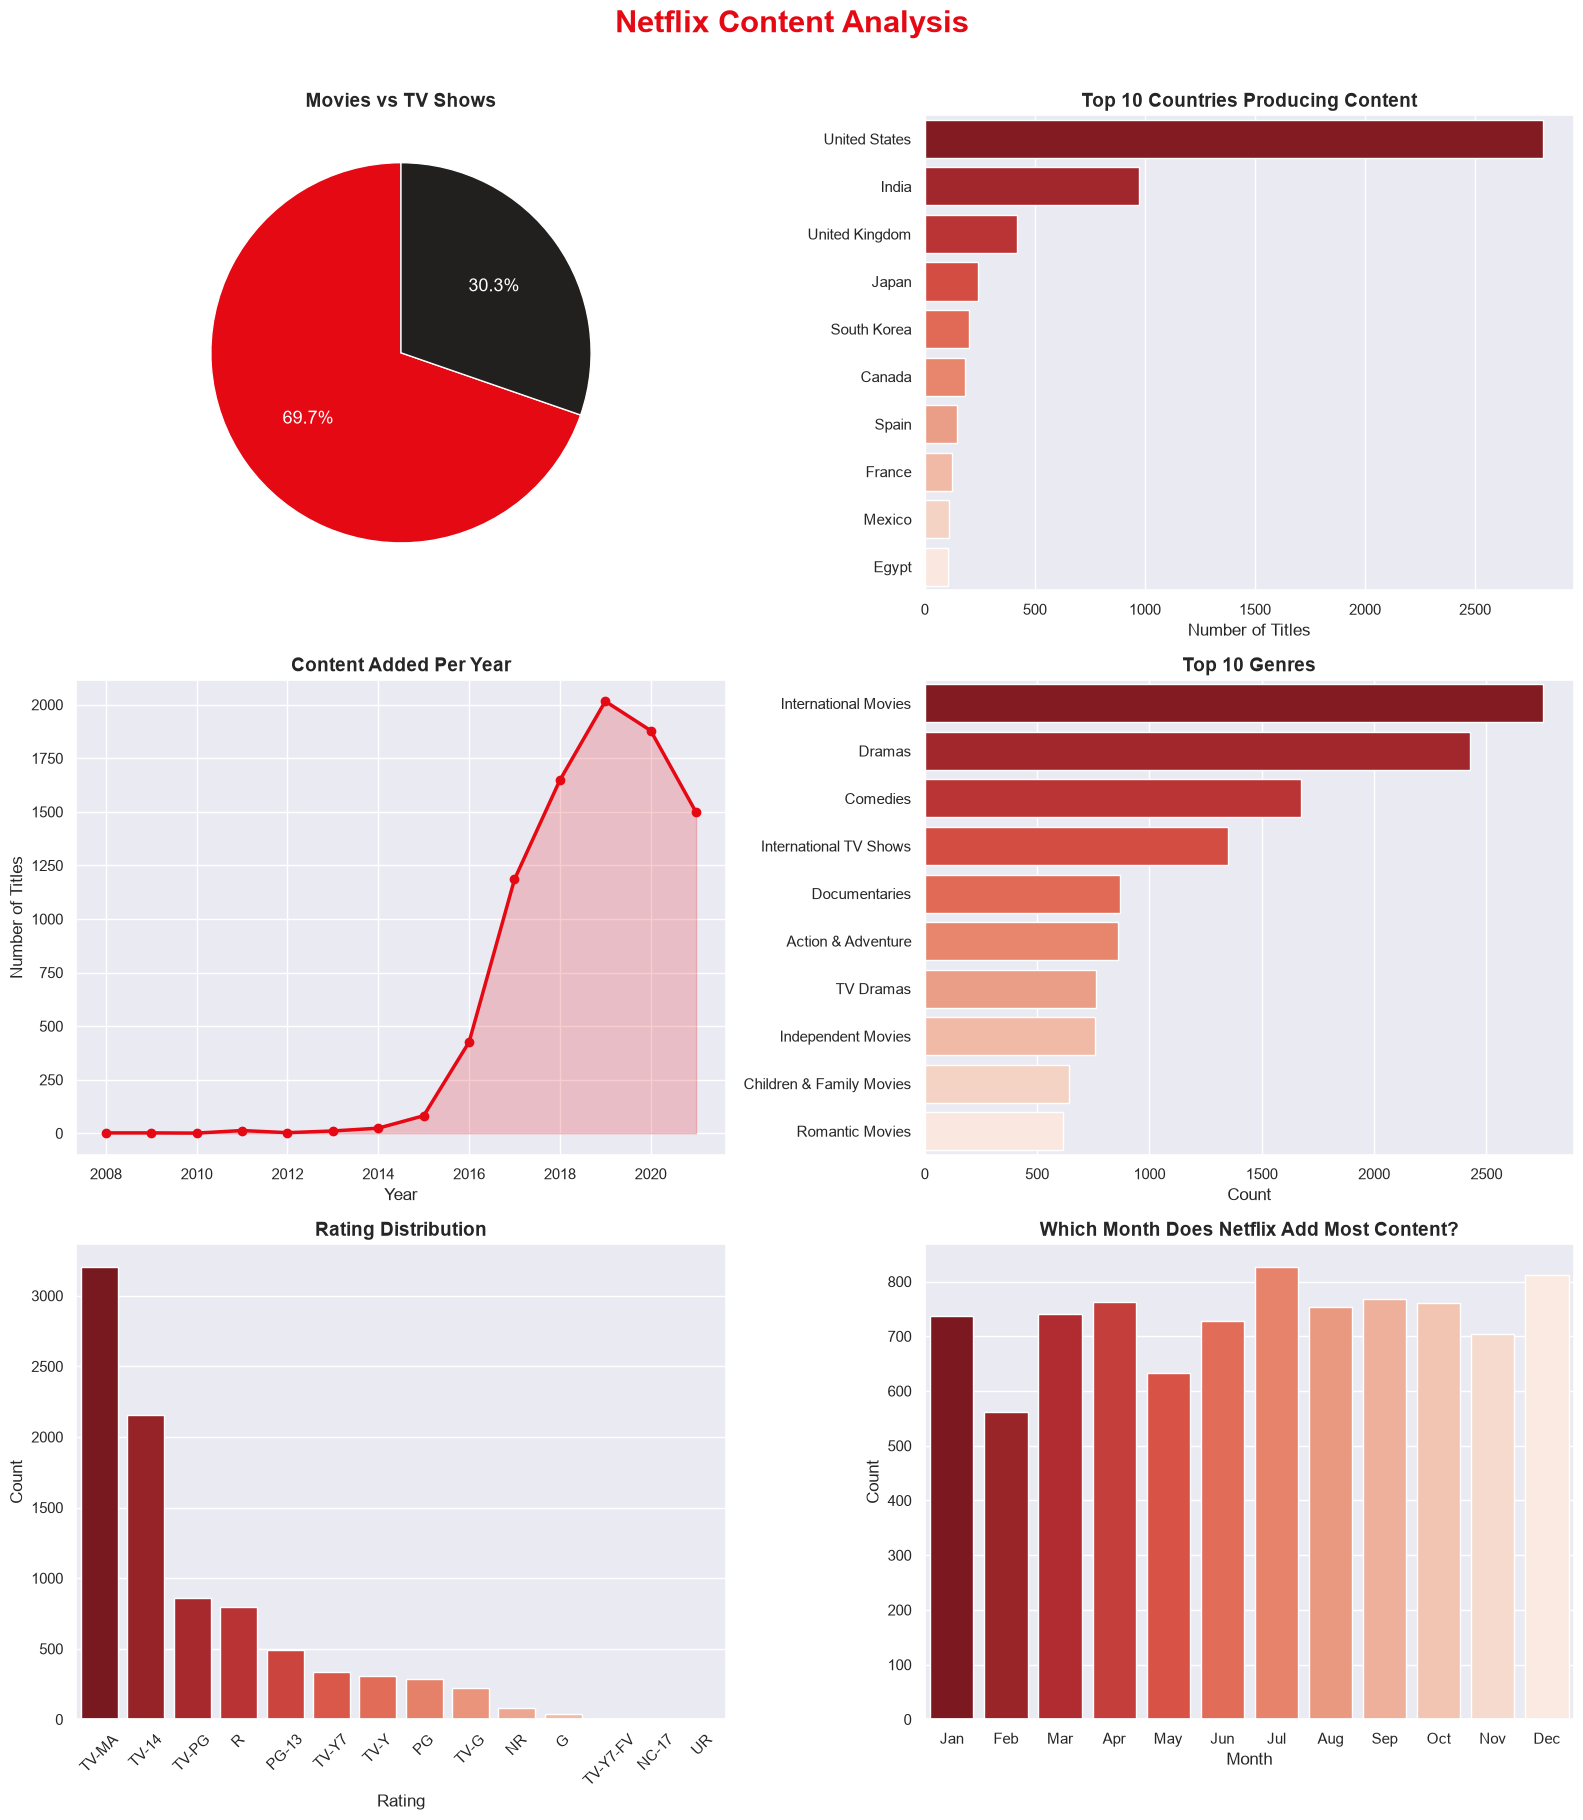

Chart saved as netflix_analysis.png !


In [5]:
# ── STEP 5: VISUALIZATIONS ────────────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Netflix Content Analysis', fontsize=22, fontweight='bold', color='#E50914', y=1.01)

# ── 1. Movies vs TV Shows — Pie Chart ─────────────────────────
type_counts = df['type'].value_counts()
axes[0, 0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
               colors=['#E50914', '#221F1F'], startangle=90,
               textprops={'color': 'white', 'fontsize': 13})
axes[0, 0].set_title('Movies vs TV Shows', fontsize=14, fontweight='bold')
axes[0, 0].set_facecolor('#141414')

# ── 2. Top 10 Countries — Horizontal Bar ──────────────────────
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index,
            ax=axes[0, 1], palette='Reds_r')
axes[0, 1].set_title('Top 10 Countries Producing Content', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Titles')
axes[0, 1].set_ylabel('')

# ── 3. Content Added Per Year — Line Chart ────────────────────
yearly = df['year_added'].value_counts().sort_index()
axes[1, 0].plot(yearly.index, yearly.values, color='#E50914',
                marker='o', linewidth=2.5, markersize=6)
axes[1, 0].fill_between(yearly.index, yearly.values, alpha=0.2, color='#E50914')
axes[1, 0].set_title('Content Added Per Year', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Number of Titles')

# ── 4. Top 10 Genres — Bar Chart ──────────────────────────────
all_genres = df['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index,
            ax=axes[1, 1], palette='Reds_r')
axes[1, 1].set_title('Top 10 Genres', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('')

# ── 5. Rating Distribution — Bar Chart ───────────────────────
rating_counts = df['rating'].value_counts()
sns.barplot(x=rating_counts.index, y=rating_counts.values,
            ax=axes[2, 0], palette='Reds_r')
axes[2, 0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Rating')
axes[2, 0].set_ylabel('Count')
axes[2, 0].tick_params(axis='x', rotation=45)

# ── 6. Content Added Per Month — Bar Chart ───────────────────
monthly = df['month_added'].value_counts().sort_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
sns.barplot(x=month_names, y=monthly.values, ax=axes[2, 1], palette='Reds_r')
axes[2, 1].set_title('Which Month Does Netflix Add Most Content?', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Month')
axes[2, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('netflix_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as netflix_analysis.png !")